# Ex 04 - Developing a Neural Network Classification Model using Transfer Learning

**NAME:**  Ramya P        **REG NO:** 212223230168           **SLOT:** 26OD1143



In [3]:
!pip install seaborn

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision import models, datasets
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [5]:
## Step 1: Load and Preprocess Data
# Define transformations for images
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize images for pre-trained model input
    transforms.ToTensor(),
    #transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  # Standard normalization for pre-trained models
])

In [6]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nFiles/folders here:")
print(os.listdir())

Current working directory:
C:\Users\admin\Documents\Deep learn\DL-Transfer-Learning-main

Files/folders here:
['.ipynb_checkpoints', 'chip_data', 'chip_data.zip', 'dataset', 'EX_4.ipynb', 'LICENSE', 'README.md']


In [11]:
dataset_path = "./dataset"

train_dataset = datasets.ImageFolder(
    root=f"{dataset_path}/train",
    transform=transform
)

test_dataset = datasets.ImageFolder(
    root=f"{dataset_path}/test",
    transform=transform
)

print("Classes:", train_dataset.classes)
print("Training images:", len(train_dataset))
print("Testing images:", len(test_dataset))

Classes: ['defect', 'notdefect']
Training images: 172
Testing images: 121


In [12]:
def show_sample_images(dataset, num_images=5):

    fig, axes = plt.subplots(
        1,
        num_images,
        figsize=(15, 4)
    )

    for i in range(num_images):

        image, label = dataset[i]

        image = image.permute(1, 2, 0)

        axes[i].imshow(image)
        axes[i].set_title(dataset.classes[label])
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

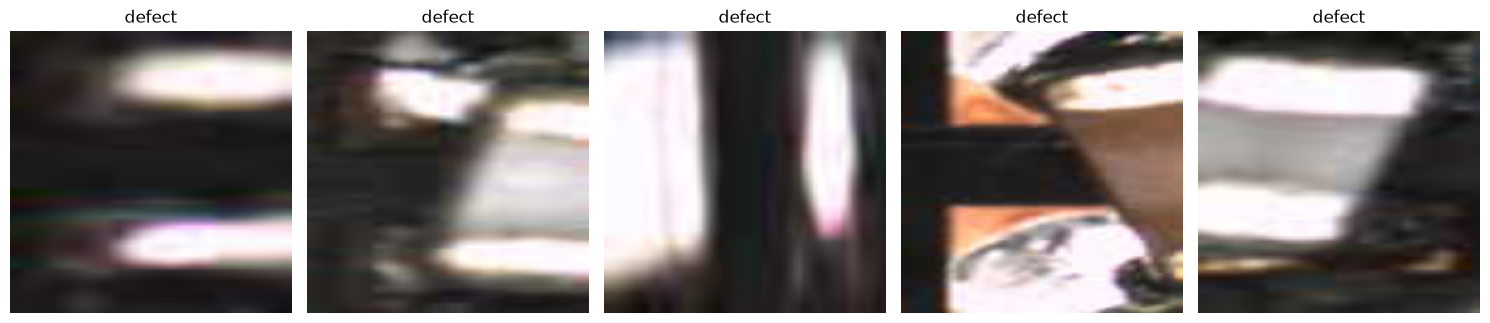

In [13]:
show_sample_images(train_dataset)

In [14]:
print(f"Total number of training samples: {len(train_dataset)}")

first_image, label = train_dataset[0]

print(f"Shape of the first image: {first_image.shape}")
print(f"First image class: {train_dataset.classes[label]}")

Total number of training samples: 172
Shape of the first image: torch.Size([3, 224, 224])
First image class: defect


In [15]:
print(f"Total number of testing samples: {len(test_dataset)}")

first_test_image, test_label = test_dataset[0]

print(f"Shape of the first test image: {first_test_image.shape}")
print(f"First test image class: {test_dataset.classes[test_label]}")

Total number of testing samples: 121
Shape of the first test image: torch.Size([3, 224, 224])
First test image class: defect


In [16]:
train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)

test_loader = DataLoader(test_dataset,batch_size=32,shuffle=False)

In [17]:
model = models.vgg19(weights=models.VGG19_Weights.DEFAULT)

print(model)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padd

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

model = model.to(device)

Using device: cuda


In [19]:
!pip install torchsummary -q

In [20]:
from torchsummary import summary

summary(model, input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 224, 224]           1,792
              ReLU-2         [-1, 64, 224, 224]               0
            Conv2d-3         [-1, 64, 224, 224]          36,928
              ReLU-4         [-1, 64, 224, 224]               0
         MaxPool2d-5         [-1, 64, 112, 112]               0
            Conv2d-6        [-1, 128, 112, 112]          73,856
              ReLU-7        [-1, 128, 112, 112]               0
            Conv2d-8        [-1, 128, 112, 112]         147,584
              ReLU-9        [-1, 128, 112, 112]               0
        MaxPool2d-10          [-1, 128, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]         295,168
             ReLU-12          [-1, 256, 56, 56]               0
           Conv2d-13          [-1, 256, 56, 56]         590,080
             ReLU-14          [-1, 256,

In [21]:
num_classes = len(train_dataset.classes)

model.classifier[6] = nn.Linear(
    model.classifier[6].in_features,
    num_classes
)

print("Number of classes:", num_classes)
print(model.classifier)

Number of classes: 2
Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=2, bias=True)
)


In [22]:
model = model.to(device)

print("Model moved to:", device)

Model moved to: cuda


In [23]:
summary(model, input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 224, 224]           1,792
              ReLU-2         [-1, 64, 224, 224]               0
            Conv2d-3         [-1, 64, 224, 224]          36,928
              ReLU-4         [-1, 64, 224, 224]               0
         MaxPool2d-5         [-1, 64, 112, 112]               0
            Conv2d-6        [-1, 128, 112, 112]          73,856
              ReLU-7        [-1, 128, 112, 112]               0
            Conv2d-8        [-1, 128, 112, 112]         147,584
              ReLU-9        [-1, 128, 112, 112]               0
        MaxPool2d-10          [-1, 128, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]         295,168
             ReLU-12          [-1, 256, 56, 56]               0
           Conv2d-13          [-1, 256, 56, 56]         590,080
             ReLU-14          [-1, 256,

In [24]:
for param in model.features.parameters():
    param.requires_grad = False

print("VGG19 feature layers frozen.")

VGG19 feature layers frozen.


In [25]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.classifier.parameters(),
    lr=0.001
)

print("Loss function and optimizer created.")

Loss function and optimizer created.


In [26]:
def train_model(model, train_loader, test_loader, num_epochs=10):
    train_losses = []
    val_losses = []
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()
            # Forward pass
            outputs = model(images)

            # Calculate loss
            loss = criterion(outputs, labels)

            # Backpropagation
            loss.backward()

            # Update weights
            optimizer.step()

            running_loss += loss.item() * images.size(0)

        epoch_train_loss = running_loss / len(train_loader.dataset)

        train_losses.append(epoch_train_loss)
        model.eval()

        running_val_loss = 0.0

        with torch.no_grad():

            for images, labels in test_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(outputs, labels)

                running_val_loss += loss.item() * images.size(0)

        epoch_val_loss = running_val_loss / len(test_loader.dataset)

        val_losses.append(epoch_val_loss)

        print(
            f"Epoch [{epoch+1}/{num_epochs}], "
            f"Train Loss: {epoch_train_loss:.4f}, "
            f"Validation Loss: {epoch_val_loss:.4f}"
        )

    print("Name:        ")
    print("Register Number:        ")

    plt.figure(figsize=(8, 6))

    plt.plot(
        range(1, num_epochs + 1),
        train_losses,
        label="Train Loss",
        marker="o"
    )

    plt.plot(
        range(1, num_epochs + 1),
        val_losses,
        label="Validation Loss",
        marker="s"
    )

    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss")

    plt.legend()
    plt.show()

    return train_losses, val_losses

In [27]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

print("Training device:", device)

Training device: cuda


In [33]:
from torch.utils.data import Subset

# Use only 200 training images
small_train_dataset = Subset(
    train_dataset,
    range(min(200, len(train_dataset)))
)

# Use only 50 test images
small_test_dataset = Subset(
    test_dataset,
    range(min(50, len(test_dataset)))
)

small_train_loader = DataLoader(
    small_train_dataset,
    batch_size=32,
    shuffle=True
)

small_test_loader = DataLoader(
    small_test_dataset,
    batch_size=32,
    shuffle=False
)

print("Training images:", len(small_train_dataset))
print("Testing images:", len(small_test_dataset))

Training images: 172
Testing images: 50


In [36]:
## Step 4: Test the Model and Compute Confusion Matrix & Classification Report
def test_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = correct / total
    print(f'Test Accuracy: {accuracy:.4f}')

    # Compute confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    print("Name: Ramya P   ")
    print("Register Number:    212223230168    ")
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=train_dataset.classes, yticklabels=train_dataset.classes)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

    # Print classification report
    print("Name: Ramya P    ")
    print("Register Number: 212223230168       ")
    print("Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))


Test Accuracy: 0.7851
Name: Ramya P   
Register Number:    212223230168    


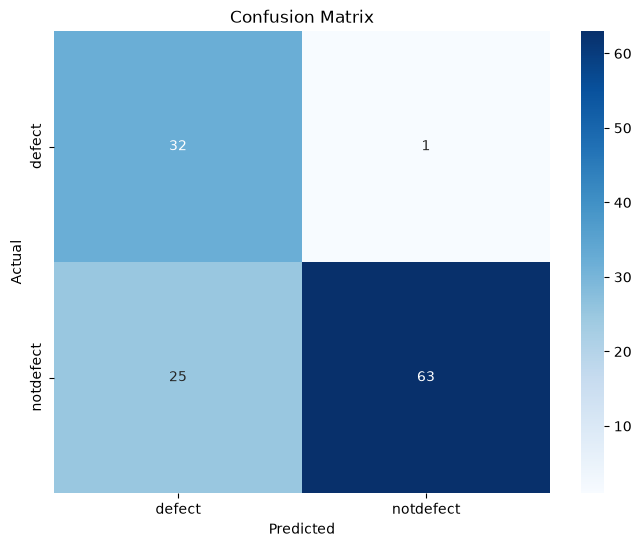

Name: Ramya P    
Register Number: 212223230168       
Classification Report:
              precision    recall  f1-score   support

      defect       0.56      0.97      0.71        33
   notdefect       0.98      0.72      0.83        88

    accuracy                           0.79       121
   macro avg       0.77      0.84      0.77       121
weighted avg       0.87      0.79      0.80       121



In [37]:
# Evaluate the model

test_model(model, test_loader)

In [40]:
def predict_image(model, image_index, dataset):

    model.eval()

    image, label = dataset[image_index]

    with torch.no_grad():

        image_tensor = image.unsqueeze(0).to(device)

        output = model(image_tensor)

        # Get the class with the highest score
        _, predicted = torch.max(output, 1)

        predicted = predicted.item()

    class_names = dataset.classes

    # Display the image
    image_to_display = transforms.ToPILImage()(image)

    plt.figure(figsize=(4, 4))

    plt.imshow(image_to_display)

    plt.title(
        f"Actual: {class_names[label]}\n"
        f"Predicted: {class_names[predicted]}"
    )

    plt.axis("off")

    plt.show()

    print(
        f"Actual: {class_names[label]}, "
        f"Predicted: {class_names[predicted]}"
    )

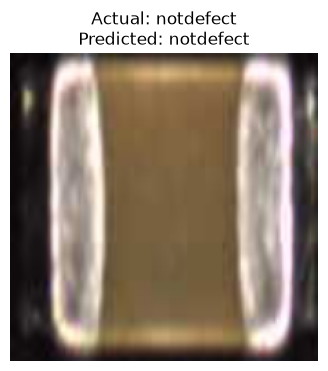

Actual: notdefect, Predicted: notdefect


In [41]:
predict_image(model,image_index=55,dataset=test_dataset)

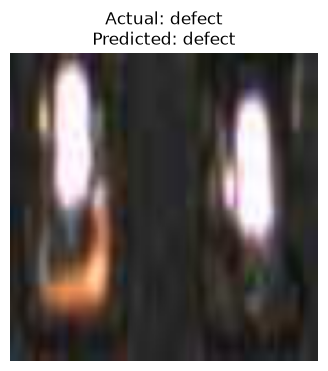

Actual: defect, Predicted: defect


In [42]:
#Example Prediction
predict_image(model, image_index=25, dataset=test_dataset)